In [12]:
# Cell 1: Imports and Data Loading
import pandas as pd
import plotly.express as px
import plotly.graph_objects as io

# Load dataset from data folder
df = pd.read_csv('../data/dataset.csv')

# Global Theme / Palette setup for CVD safety and clean visual hierarchy
COLOR_HIGHLIGHT = "#2B5C8F"  # Dark Teal/Blue
COLOR_SECONDARY = "#E66101"  # Colorblind-safe Orange
COLOR_GREY = "#9DA4B0"       # Muted Grey
COLOR_MUTED = "#E5E7EB"      # Background/Grid Grey

def apply_clean_theme(fig):
    fig.update_layout(
        template="plotly_white",
        font_family="Inter, Arial, sans-serif",
        font_color="#1F2937",
        title_font_size=18,
        title_font_family="Inter, Arial, sans-serif",
        margin=dict(l=40, r=40, t=60, b=40),
        plot_bgcolor="#FFFFFF",
        paper_bgcolor="#FFFFFF"
    )
    fig.update_xaxes(showgrid=False, zeroline=False)
    fig.update_yaxes(showgrid=True, gridcolor="#F3F4F6", zeroline=False)
    return fig

print(f"Dataset successfully loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset successfully loaded with 2864 rows and 21 columns.


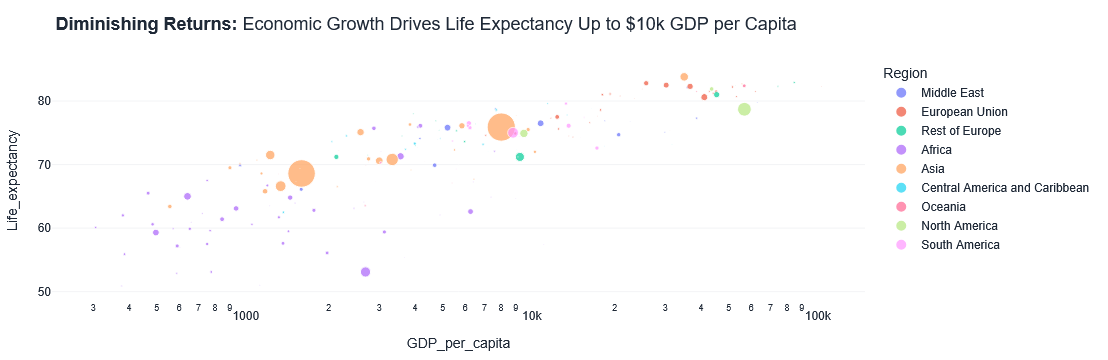

In [13]:
# Q2: How does GDP per Capita relate to Life Expectancy across different regions?
fig2 = px.scatter(
    df[df['Year'] == 2015], x='GDP_per_capita', y='Life_expectancy',
    size='Population_mln', color='Region', hover_name='Country',
    log_x=True,
    title="<b>Diminishing Returns:</b> Economic Growth Drives Life Expectancy Up to $10k GDP per Capita"
)
apply_clean_theme(fig2)
fig2.show()

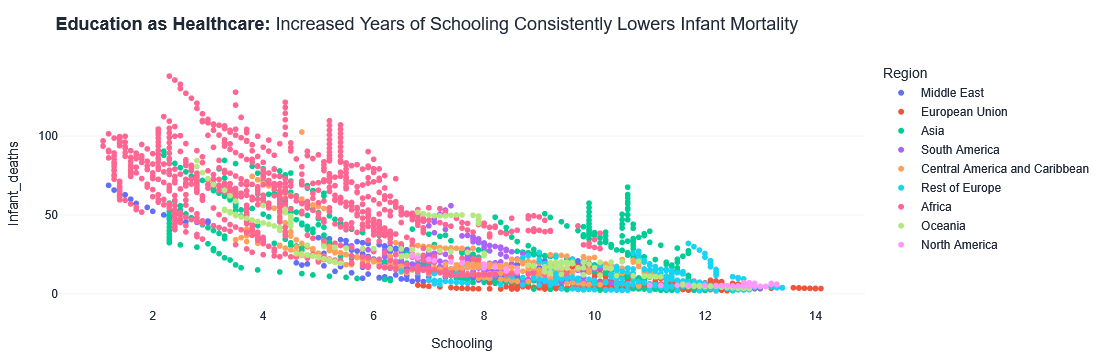

In [15]:
# Q3: Does higher Schooling correlate with reduced Infant Mortality across Regions?
fig3 = px.scatter(
    df,
    x="Schooling",
    y="Infant_deaths",
    color="Region",
    title="<b>Education as Healthcare:</b> Increased Years of Schooling Consistently Lowers Infant Mortality"
)

apply_clean_theme(fig3)
fig3.show()

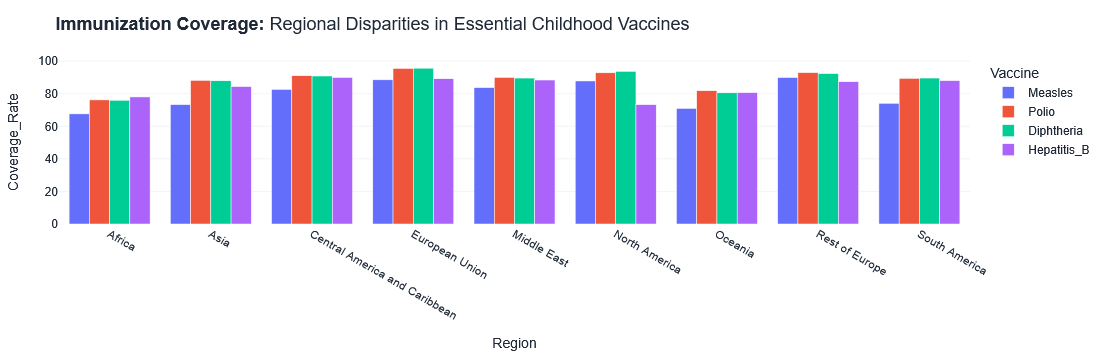

In [16]:
# Q4: How do Immunization rates (Measles, Polio, Diphtheria, Hep B) impact Adult Mortality across income levels?
imm_df = df.groupby('Region')[['Measles', 'Polio', 'Diphtheria', 'Hepatitis_B']].mean().reset_index()
imm_melted = imm_df.melt(id_vars='Region', var_name='Vaccine', value_name='Coverage_Rate')

fig4 = px.bar(
    imm_melted, x='Region', y='Coverage_Rate', color='Vaccine', barmode='group',
    title="<b>Immunization Coverage:</b> Regional Disparities in Essential Childhood Vaccines"
)
apply_clean_theme(fig4)
fig4.show()

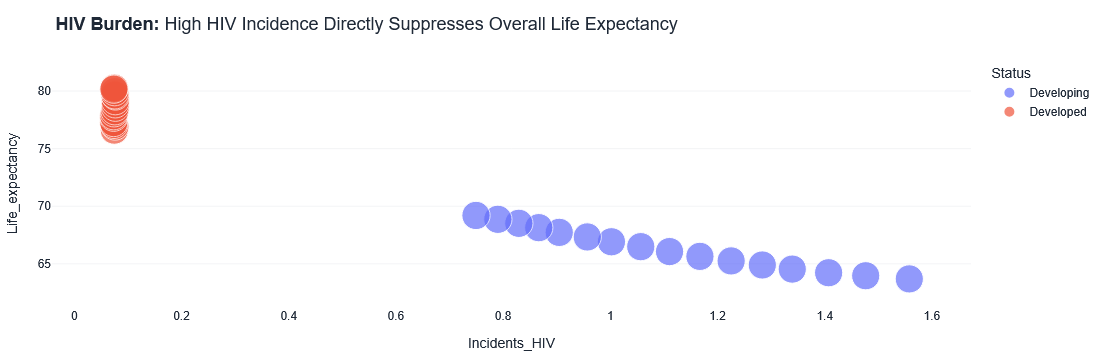

In [17]:
# Q5: What is the trajectory of Incident HIV rates compared to Life Expectancy in developing vs developed nations?
df_hiv = df.groupby(['Year', 'Economy_status_Developed'])[['Incidents_HIV', 'Life_expectancy']].mean().reset_index()
df_hiv['Status'] = df_hiv['Economy_status_Developed'].map({1: 'Developed', 0: 'Developing'})

fig5 = px.scatter(
    df_hiv, x='Incidents_HIV', y='Life_expectancy', color='Status', size='Year',
    title="<b>HIV Burden:</b> High HIV Incidence Directly Suppresses Overall Life Expectancy"
)
apply_clean_theme(fig5)
fig5.show()

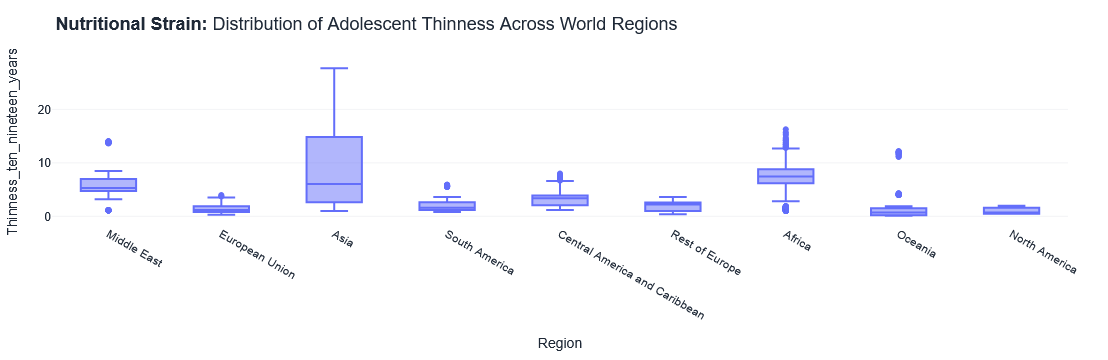

In [18]:
# Q6: How does adolescent thinness (10-19 years) compare to childhood thinness (5-9 years) across Regions?
fig6 = px.box(
    df, x='Region', y='Thinness_ten_nineteen_years',
    title="<b>Nutritional Strain:</b> Distribution of Adolescent Thinness Across World Regions"
)
apply_clean_theme(fig6)
fig6.show()

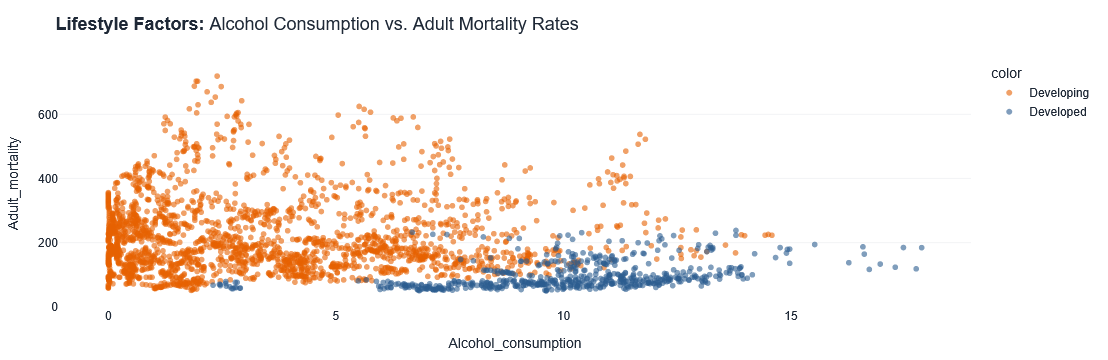

In [19]:
# Q7: What is the relationship between Alcohol Consumption and Adult Mortality across developed vs developing economies?
fig7 = px.scatter(
    df, x='Alcohol_consumption', y='Adult_mortality',
    color=df['Economy_status_Developed'].map({1: 'Developed', 0: 'Developing'}),
    color_discrete_map={'Developed': COLOR_HIGHLIGHT, 'Developing': COLOR_SECONDARY},
    opacity=0.6,
    title="<b>Lifestyle Factors:</b> Alcohol Consumption vs. Adult Mortality Rates"
)
apply_clean_theme(fig7)
fig7.show()

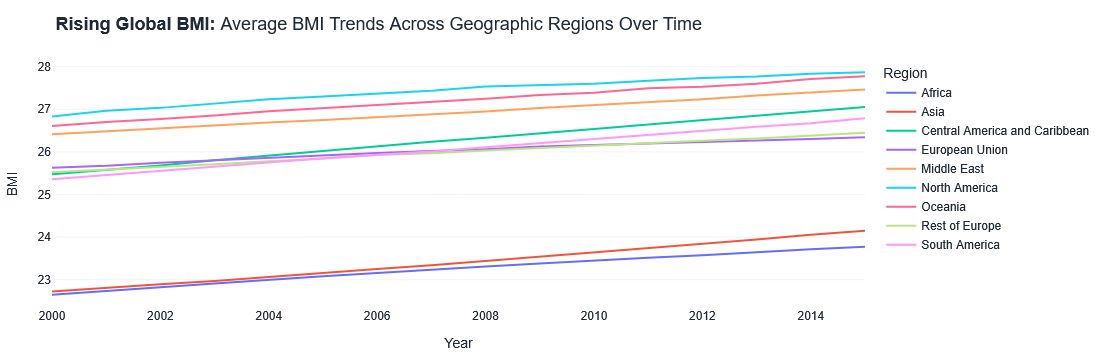

In [20]:
# Q8: How has the national BMI distribution shifted over time per region?
bmi_region = df.groupby(['Year', 'Region'])['BMI'].mean().reset_index()
fig8 = px.line(
    bmi_region, x='Year', y='BMI', color='Region',
    title="<b>Rising Global BMI:</b> Average BMI Trends Across Geographic Regions Over Time"
)
apply_clean_theme(fig8)
fig8.show()

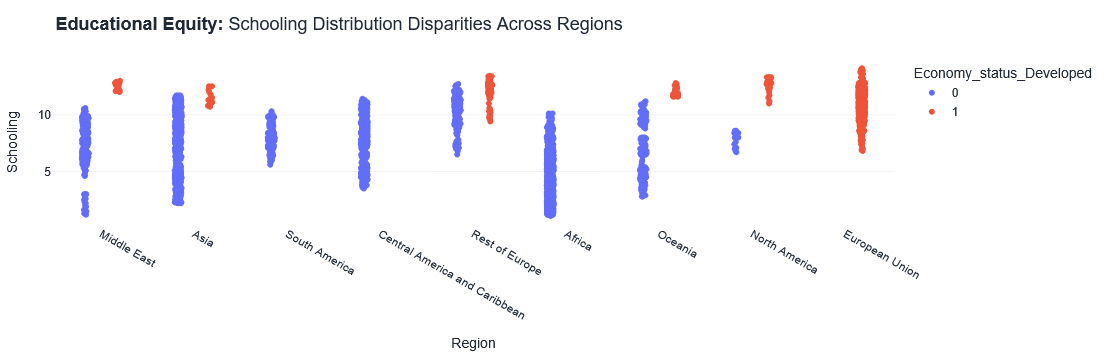

In [21]:
# Q9: Which regions exhibit the strongest correlation between Schooling and GDP per Capita?
fig9 = px.strip(
    df, x='Region', y='Schooling', color='Economy_status_Developed',
    title="<b>Educational Equity:</b> Schooling Distribution Disparities Across Regions"
)
apply_clean_theme(fig9)
fig9.show()

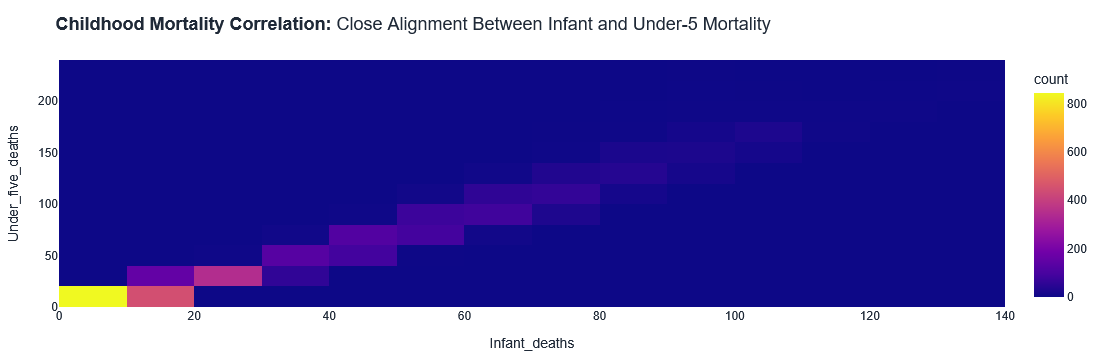

In [22]:
# Q10: How does Under-Five Mortality compare against Infant Mortality globally across years?
fig10 = px.density_heatmap(
    df, x='Infant_deaths', y='Under_five_deaths',
    title="<b>Childhood Mortality Correlation:</b> Close Alignment Between Infant and Under-5 Mortality"
)
apply_clean_theme(fig10)
fig10.show()